#AI password strength verification model.

 Mount Google Drive & Install Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Define save directory path
SAVE_DIR = '/content/drive/MyDrive/password_project/datasets'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f" Drive mounted. Save directory: {SAVE_DIR}")

Mounted at /content/drive
 Drive mounted. Save directory: /content/drive/MyDrive/password_project/datasets


## Preprocessing Data

### 1: Generate sample of password

Define All Policy Rules

In [ ]:
POLICIES = {
    "weak": {
        "length_range": (4, 7),
        "use_upper": False,
        "use_lower": True,
        "use_digits": False,
        "use_special": False,
        "allow_common_patterns": True,   # 123, abc, etc.
        "label": 0
    },
    "medium": {
        "length_range": (8, 11),
        "use_upper": True,
        "use_lower": True,
        "use_digits": True,
        "use_special": False,
        "allow_common_patterns": False,
        "label": 1
    },
    "strong": {
        "length_range": (12, 20),
        "use_upper": True,
        "use_lower": True,
        "use_digits": True,
        "use_special": True,
        "allow_common_patterns": False,
        "min_special": 2,
        "min_digits": 2,
        "min_upper": 2,
        "label": 2
    }
}

print("Policies defined:")
for k, v in POLICIES.items():
    print(f"   [{k.upper()}] → label={v['label']} | length={v['length_range']}")



Policies defined:
   [WEAK] → label=0 | length=(4, 7)
   [MEDIUM] → label=1 | length=(8, 11)
   [STRONG] → label=2 | length=(12, 20)


Build the Generator

In [ ]:
import secrets
import string
from dataclasses import dataclass
from typing import Callable, Dict


# Character Pools

LOWER   = string.ascii_lowercase
UPPER   = string.ascii_uppercase
DIGITS  = string.digits
SPECIAL = "!@#$%^&*()_+-=[]{}|;:,.<>?"
ALL     = LOWER + UPPER + DIGITS + SPECIAL


# Common Weak Data

COMMON_WORDS = [
    "password", "admin", "login", "user",
    "welcome", "dragon", "football",
    "shadow", "master", "monkey"
]

COMMON_PATTERNS = [
    "123456", "12345678", "qwerty", "abc123",
    "111111", "000000", "654321"
]

COMMON_NAMES = [
    "mohamed", "ahmed", "sarah", "amina",
    "youssef", "karim", "lina"
]

CURRENT_YEARS = ["2023", "2024", "2025", "2026"]

KEYBOARD_SEQUENCES = ["qwerty", "asdfgh", "zxcvbn"]

# Policy Configuration

@dataclass
class PasswordPolicy:
    min_length: int
    min_upper: int
    min_lower: int
    min_digits: int
    min_special: int
    label: int

POLICIES: Dict[str, PasswordPolicy] = {
    "weak":   PasswordPolicy(4,  0, 0, 0, 0, label=0),
    "medium": PasswordPolicy(8,  1, 1, 1, 0, label=1),
    "strong": PasswordPolicy(12, 2, 2, 2, 2, label=2),
}

# Helper Functions

def secure_choice(pool: str) -> str:
    return secrets.choice(pool)

def secure_choices(pool: str, k: int):
    return [secure_choice(pool) for _ in range(k)]

def shuffle_password(pwd_list):
    secrets.SystemRandom().shuffle(pwd_list)
    return ''.join(pwd_list)

# Weak Generator

def generate_weak() -> str:
    strategy = secrets.choice(["common", "name_year", "digits", "repeat", "sequence"])

    if strategy == "common":
        return secrets.choice(COMMON_WORDS)

    elif strategy == "name_year":
        return secrets.choice(COMMON_NAMES) + secrets.choice(CURRENT_YEARS)

    elif strategy == "digits":
        return ''.join(secure_choices(DIGITS, secrets.randbelow(4) + 4))

    elif strategy == "repeat":
        char = secure_choice(LOWER)
        return char * (secrets.randbelow(3) + 4)

    else:
        return secrets.choice(KEYBOARD_SEQUENCES)


# Medium Generator

def generate_medium() -> str:
    policy = POLICIES["medium"]
    length = secrets.randbelow(4) + policy.min_length  # 8–11

    pwd = []

    # Enforce minimum requirements
    pwd += secure_choices(UPPER, policy.min_upper)
    pwd += secure_choices(LOWER, policy.min_lower)
    pwd += secure_choices(DIGITS, policy.min_digits)

    remaining = length - len(pwd)
    pool = LOWER + UPPER + DIGITS
    pwd += secure_choices(pool, remaining)

    return shuffle_password(pwd)



# Strong Generator

def generate_strong() -> str:
    policy = POLICIES["strong"]
    length = secrets.randbelow(9) + policy.min_length  # 12–20

    pwd = []

    pwd += secure_choices(UPPER, policy.min_upper)
    pwd += secure_choices(LOWER, policy.min_lower)
    pwd += secure_choices(DIGITS, policy.min_digits)
    pwd += secure_choices(SPECIAL, policy.min_special)

    remaining = length - len(pwd)
    pwd += secure_choices(ALL, remaining)

    return shuffle_password(pwd)


# Generator Mapping

GENERATORS: Dict[str, Callable[[], str]] = {
    "weak": generate_weak,
    "medium": generate_medium,
    "strong": generate_strong,
}

In [ ]:
# Quick test
LABEL_MAP = {"weak": 0, "medium": 1, "strong": 2}
print("Sample Passwords:")
for strength, gen in GENERATORS.items():
    samples = [gen() for _ in range(3)]
    label   = POLICIES[strength].label
    for s in samples:
        print(f"   [{strength.upper():6}] label={label} | {s}")

Sample Passwords:
   [WEAK  ] label=0 | 970401
   [WEAK  ] label=0 | oooooo
   [WEAK  ] label=0 | youssef2024
   [MEDIUM] label=1 | 5yE7XwtNao7
   [MEDIUM] label=1 | r2lMXq82qYs
   [MEDIUM] label=1 | tbvJrC6MN9
   [STRONG] label=2 | |}5!kR+cI_3*-
   [STRONG] label=2 | f$gGJZ7#}x64E:i
   [STRONG] label=2 | >n=2YlDVr15m


Generate 350K Passwords

In [ ]:
import pandas as pd
from tqdm import tqdm

TOTAL     = 350_000
PER_CLASS = TOTAL // 3
CLASSES   = ["weak", "medium", "strong"]

LABEL_MAP = {"weak": 0, "medium": 1, "strong": 2}

records = []

for strength in CLASSES:
    gen   = GENERATORS[strength]
    label = LABEL_MAP[strength]
    print(f"⚙️  Generating {PER_CLASS:,} {strength.upper()} passwords...")

    seen  = set()
    count = 0

    with tqdm(total=PER_CLASS) as pbar:
        while count < PER_CLASS:
            pwd = gen()
            if pwd not in seen:
                seen.add(pwd)
                records.append({"password": pwd, "strength": label, "source": "rule_based"})
                count += 1
                pbar.update(1)

# Shuffle
df_rulebased = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n Generation complete!")
print(f"   Total records : {len(df_rulebased):,}")
print(f"\n Class distribution:")
print(df_rulebased['strength'].value_counts().sort_index())

⚙️  Generating 116,666 WEAK passwords...


100%|██████████| 116666/116666 [00:07<00:00, 15917.45it/s]


⚙️  Generating 116,666 MEDIUM passwords...


100%|██████████| 116666/116666 [00:03<00:00, 30092.08it/s]


⚙️  Generating 116,666 STRONG passwords...


100%|██████████| 116666/116666 [00:07<00:00, 16522.30it/s]



 Generation complete!
   Total records : 349,998

 Class distribution:
strength
0    116666
1    116666
2    116666
Name: count, dtype: int64


Validate Quality

In [ ]:
import math

SPECIAL = "!@#$%^&*()_+-=[]{}|;:,.<>?"

def password_entropy(pwd):
    if not pwd: return 0
    freq = [pwd.count(c)/len(pwd) for c in set(pwd)]
    return round(-sum(p * math.log2(p) for p in freq), 4)

def validate_sample(df, n=5):
    print("=" * 60)
    for label, name in [(0,"WEAK"), (1,"MEDIUM"), (2,"STRONG")]:
        subset = df[df['strength'] == label].sample(n, random_state=42)
        print(f"\n🔍 {name} Samples:")
        for _, row in subset.iterrows():
            pwd = str(row['password'])
            ent = password_entropy(pwd)
            has_upper   = any(c.isupper() for c in pwd)
            has_digit   = any(c.isdigit() for c in pwd)
            has_special = any(c in SPECIAL for c in pwd)
            print(f"   '{pwd}'")
            print(f"    len={len(pwd)} | entropy={ent} | upper={has_upper} | digit={has_digit} | special={has_special}")
        print("-" * 60)

validate_sample(df_rulebased)
print(f"\n Duplicate check: {df_rulebased['password'].duplicated().sum()} duplicates found")
print(f" Total samples  : {len(df_rulebased):,}")


🔍 WEAK Samples:
   '71886'
    len=5 | entropy=1.9219 | upper=False | digit=True | special=False
   '369588'
    len=6 | entropy=2.2516 | upper=False | digit=True | special=False
   '461642'
    len=6 | entropy=1.9183 | upper=False | digit=True | special=False
   '4684742'
    len=7 | entropy=2.1281 | upper=False | digit=True | special=False
   '978048'
    len=6 | entropy=2.2516 | upper=False | digit=True | special=False
------------------------------------------------------------

🔍 MEDIUM Samples:
   '61bKVY1r'
    len=8 | entropy=2.75 | upper=True | digit=True | special=False
   '5MmMFA3OhS'
    len=10 | entropy=3.1219 | upper=True | digit=True | special=False
   'mkSU5v2Nyvu'
    len=11 | entropy=3.2776 | upper=True | digit=True | special=False
   'Z2Xm3pJDKM'
    len=10 | entropy=3.3219 | upper=True | digit=True | special=False
   'tDdJ9Rpm8wq'
    len=11 | entropy=3.4594 | upper=True | digit=True | special=False
------------------------------------------------------------

🔍 ST

Save to Drive

In [ ]:
save_path = f"{SAVE_DIR}/rule_based_350k.csv"
df_rulebased.to_csv(save_path, index=False)

print(f" Saved successfully!")
print(f"   📁 Path  : {save_path}")
print(f"   📦 Size  : {len(df_rulebased):,} rows")
print(f"   💾 File  : {round(os.path.getsize(save_path)/1024/1024, 2)} MB")

 Saved successfully!
   📁 Path  : /content/drive/MyDrive/password_project/datasets/rule_based_350k.csv
   📦 Size  : 349,998 rows
   💾 File  : 8.2 MB


### 2: Adversarial/Edge Cases Generation

In [ ]:
import secrets
import string
from typing import Callable


#  Character Pools
LOWER   = string.ascii_lowercase
UPPER   = string.ascii_uppercase
DIGITS  = string.digits
SPECIAL = "!@#$%^&*()_+-=[]{}|;:,.<>?"
ALL     = LOWER + UPPER + DIGITS + SPECIAL


#  Leet Speak Mapping
LEET_MAP = {
    'a': '@', 'e': '3', 'i': '1', 'o': '0',
    's': '$', 't': '7', 'l': '1', 'g': '9', 'b': '8'
}

def apply_leet(word: str, intensity: float = 0.5) -> str:
    result = []
    for ch in word:
        if ch.lower() in LEET_MAP and secrets.randbelow(100) / 100 < intensity:
            result.append(LEET_MAP[ch.lower()])
        else:
            result.append(ch)
    return ''.join(result)

def apply_full_leet(word: str) -> str:
    """Replace ALL possible characters → max leet."""
    return ''.join(LEET_MAP.get(ch.lower(), ch) for ch in word)


#  Base Pools
COMMON_WORDS = [
    "password", "welcome", "admin", "letmein", "football",
    "dragon", "shadow", "monkey", "sunshine", "princess",
    "superman", "batman", "master", "hunter", "summer",
    "winter", "spring", "autumn", "flower", "thunder",
    "rocket", "coffee", "matrix", "falcon", "ranger",
    "wizard", "silver", "golden", "secret", "access"
]

NAMES = [
    "Mohamed", "Ahmed", "Sarah", "Youssef", "Karim", "Lina", "Amina",
    "Omar", "Fatima", "Ali", "Hassan", "Nour", "Rania", "Tarek",
    "Hana", "Sami", "Dina", "Khaled", "Mona", "Nadia", "Yasmine",
    "Bilal", "Reem", "Ziad", "Layla", "Walid", "Iman", "Faris",
    "James", "Emma", "Oliver", "Sophia", "Lucas", "Mia", "Noah"
]

YEARS = [
    "2018", "2019", "2020", "2021", "2022",
    "2023", "2024", "2025", "2026"
]

KEYBOARD_PATTERNS = [
    "qwerty", "asdfgh", "zxcvbn", "1qaz2wsx",
    "1q2w3e4r", "zaq12wsx", "qazwsx", "poiuyt",
    "mnbvcx", "lkjhgf", "0987654321", "qwertyuiop"
]

TRULY_STRONG_BASES = [
    "QuantumLeap", "CrimsonTide", "GlacierPeak", "EchoChamber",
    "SphinxRiddle", "WindmillPath", "PurpleElephant", "CorrectBattery",
    "TroubadourSong", "HorizonSunset", "TurbineEngine", "NebulaDrift",
    "ArcticStorm", "CosmicRay", "ThunderVault", "PhantomCircuit"
]


# Mutation Engine
SUFFIXES = ["123", "123!", "2024!", "@1", "!1", "#1", "007", "99!", "1!", "01!"]
PREFIXES = ["@", "!", "#", "The", "My", "New", "Old", "Mr", "Dr"]

def add_common_suffix(pwd: str) -> str:
    return pwd + secrets.choice(SUFFIXES)

def add_common_prefix(pwd: str) -> str:
    return secrets.choice(PREFIXES) + pwd

def random_case_mix(word: str) -> str:
    return ''.join(
        ch.upper() if secrets.randbelow(2) else ch.lower()
        for ch in word
    )

def random_special_insert(pwd: str) -> str:
    pos = secrets.randbelow(len(pwd))
    return pwd[:pos] + secrets.choice(SPECIAL) + pwd[pos:]

def inject_digit_block(pwd: str) -> str:
    digits = ''.join(secrets.choice(DIGITS) for _ in range(2))
    pos    = secrets.randbelow(len(pwd))
    return pwd[:pos] + digits + pwd[pos:]


# WEAK GENERATORS (label = 0)

def generate_deceptive_weak() -> str:
    """
    CommonWord + case mix + leet + suffix
    LOOKS strong (upper+digit+special) but IS weak (word-based)
    e.g: 'PR1NcE$$@1', 'F00Tb@ll2024!'
    """
    base = secrets.choice(COMMON_WORDS)
    base = random_case_mix(base)
    base = apply_leet(base, intensity=0.4)
    base = add_common_suffix(base)
    return base


def generate_full_leet_weak() -> str:
    """
    Full leet substitution on common word → still weak (known map)
    e.g: 'p@$$w0rd!1', '@dm1n2024!'
    """
    base = secrets.choice(COMMON_WORDS)
    base = apply_full_leet(base)
    base = random_case_mix(base)
    base = add_common_suffix(base)
    return base


def generate_keyboard_walk() -> str:
    """
    Keyboard sequence + decoration → weak (sequential pattern)
    e.g: 'Qwerty@1', '1qaz2wsx123!'
    """
    base = secrets.choice(KEYBOARD_PATTERNS)
    base = base.capitalize()
    return add_common_suffix(base)


def generate_name_year_combo() -> str:
    """
    Name + year + special → weak (highly predictable)
    e.g: 'Ahmed2024!', '@Karim2025'
    """
    name    = secrets.choice(NAMES)
    year    = secrets.choice(YEARS)
    special = secrets.choice(["!", "@", "#", "$", "%"])

    variant = secrets.randbelow(3)
    if variant == 0:
        return name + year + special
    elif variant == 1:
        return name + special + year
    else:
        return special + name + year


def generate_repeat_pattern_weak() -> str:
    """
    Repeated char block + decoration → weak (no entropy)
    e.g: 'Aaaa@1234', 'Zzzz!2024'
    """
    char   = secrets.choice(LOWER)
    repeat = secrets.randbelow(3) + 3
    base   = char * repeat
    base   = base.capitalize()
    return add_common_suffix(base)


def generate_prefix_word_weak() -> str:
    """
    Prefix + common word + digits → weak (still word-based)
    e.g: 'MyPassword42', 'NewDragon99!'
    """
    base = secrets.choice(COMMON_WORDS).capitalize()
    base = add_common_prefix(base)
    base = inject_digit_block(base)
    if secrets.randbelow(2):
        base += secrets.choice(["!", "@", "#"])
    return base


# MEDIUM GENERATORS (label = 1)

def generate_disguised_medium() -> str:
    """
    Short (4–6) but all char types present → medium (borderline)
    e.g: 'aB3!', 'Zx9#kL'
    """
    length = secrets.randbelow(3) + 4
    pwd = [
        secrets.choice(LOWER),
        secrets.choice(UPPER),
        secrets.choice(DIGITS),
        secrets.choice(SPECIAL)
    ]
    while len(pwd) < length:
        pwd.append(secrets.choice(ALL))
    secrets.SystemRandom().shuffle(pwd)
    return ''.join(pwd)


def generate_medium_no_special() -> str:
    """
    Good length + upper + digit but NO special char → medium
    e.g: 'SunnyDay42Ax', 'Dragon99Hunter'
    """
    base   = secrets.choice(COMMON_WORDS).capitalize()
    pool   = LOWER + UPPER + DIGITS
    extra  = ''.join(secrets.choice(pool) for _ in range(secrets.randbelow(4) + 3))
    digits = ''.join(secrets.choice(DIGITS) for _ in range(2))
    return base + digits + extra


# STRONG GENERATORS (label = 2)

def generate_truly_strong() -> str:
    """
    High-entropy base + leet + special insert + random suffix
    e.g: 'Qu@n7umL3@pWU.88TSG'
    """
    base  = secrets.choice(TRULY_STRONG_BASES)
    base  = apply_leet(base, intensity=0.6)
    base  = random_special_insert(base)
    base  = random_special_insert(base)

    extra = (
        [secrets.choice(UPPER)]   +
        [secrets.choice(DIGITS)]  +
        [secrets.choice(SPECIAL)] +
        [secrets.choice(ALL) for _ in range(secrets.randbelow(6) + 4)]
    )
    secrets.SystemRandom().shuffle(extra)
    return base + ''.join(extra)


def generate_passphrase_strong() -> str:
    """
    Multi-word passphrase style with substitutions → strong
    e.g: 'Coral#Hammer7!Drift@Volt'
    """
    words  = secrets.SystemRandom().sample(TRULY_STRONG_BASES, 2)
    words  = [apply_leet(w, intensity=0.4) for w in words]
    sep1   = secrets.choice(SPECIAL)
    sep2   = secrets.choice(SPECIAL)
    digits = ''.join(secrets.choice(DIGITS) for _ in range(2))
    return words[0] + sep1 + digits + sep2 + words[1]



# Generator Registry

ADVERSARIAL_GENERATORS: list[tuple[Callable, int, str]] = [
    (generate_deceptive_weak,      0, "deceptive_weak"),
    (generate_full_leet_weak,      0, "full_leet_weak"),
    (generate_keyboard_walk,       0, "keyboard_walk"),
    (generate_name_year_combo,     0, "name_year_combo"),
    (generate_repeat_pattern_weak, 0, "repeat_pattern_weak"),
    (generate_prefix_word_weak,    0, "prefix_word_weak"),
    (generate_disguised_medium,    1, "disguised_medium"),
    (generate_medium_no_special,   1, "medium_no_special"),
    (generate_truly_strong,        2, "truly_strong"),
    (generate_passphrase_strong,   2, "passphrase_strong"),
]



Generate 250K Adversarial Passwords

In [ ]:
import pandas as pd
from tqdm import tqdm

ADVERSARIAL_TOTAL = 250_000

# Generator registry (aligned with new functions)
ADVERSARIAL_GENERATORS = [
    (generate_deceptive_weak,    0, "deceptive_weak"),
    (generate_keyboard_walk,     0, "keyboard_walk"),
    (generate_name_year_combo,   0, "name_year_combo"),
    (generate_disguised_medium,  1, "disguised_medium"),
    (generate_truly_strong,      2, "truly_strong"),
]

# Weights per strategy
WEIGHTS = {
    "deceptive_weak":   0.30,   # 75K  ← hardest edge case, most important
    "keyboard_walk":    0.20,   # 50K
    "name_year_combo":  0.20,   # 50K
    "disguised_medium": 0.15,   # 37.5K
    "truly_strong":     0.15,   # 37.5K
}

strategy_counts = {
    name: int(ADVERSARIAL_TOTAL * WEIGHTS[name])
    for _, _, name in ADVERSARIAL_GENERATORS
}

records = []
seen    = set()

for gen_fn, label, strategy_name in ADVERSARIAL_GENERATORS:
    target = strategy_counts[strategy_name]
    count  = 0
    print(f"⚙️  [{label}] {strategy_name:22} → generating {target:,}")

    with tqdm(total=target, leave=False) as pbar:
        max_attempts = target * 30
        attempts     = 0

        while count < target and attempts < max_attempts:
            pwd      = gen_fn()
            attempts += 1
            if pwd not in seen:
                seen.add(pwd)
                records.append({
                    "password": pwd,
                    "strength": label,
                    "source":   "adversarial",
                    "strategy": strategy_name
                })
                count += 1
                pbar.update(1)

        if count < target:
            print(f"   ⚠️  Only {count:,}/{target:,} for '{strategy_name}' (pool exhausted)")

# Shuffle
df_adversarial = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n Adversarial generation complete!")
print(f"   Total records : {len(df_adversarial):,}")
print(f"\n Label distribution:")
print(df_adversarial['strength'].value_counts().sort_index())
print(f"\n Strategy distribution:")
print(df_adversarial['strategy'].value_counts())

⚙️  [0] deceptive_weak         → generating 75,000


⚙️  [0] keyboard_walk          → generating 50,000


   ⚠️  Only 120/50,000 for 'keyboard_walk' (pool exhausted)
⚙️  [0] name_year_combo        → generating 50,000


   ⚠️  Only 4,725/50,000 for 'name_year_combo' (pool exhausted)
⚙️  [1] disguised_medium       → generating 37,500


⚙️  [2] truly_strong           → generating 37,500



 Adversarial generation complete!
   Total records : 154,845

 Label distribution:
strength
0    79845
1    37500
2    37500
Name: count, dtype: int64

 Strategy distribution:
strategy
deceptive_weak      75000
disguised_medium    37500
truly_strong        37500
name_year_combo      4725
keyboard_walk         120
Name: count, dtype: int64


Validate Adversarial Quality

In [ ]:
import math

def password_entropy(pwd):
    if not pwd: return 0
    freq = [pwd.count(c) / len(pwd) for c in set(pwd)]
    return round(-sum(p * math.log2(p) for p in freq), 4)

def validate_adversarial(df, n=4):
    print("=" * 65)
    print("ADVERSARIAL VALIDATION — Edge Case Samples")
    print("=" * 65)

    LABEL_NAMES = {0: "WEAK", 1: "MEDIUM", 2: "STRONG"}

    for strategy in df['strategy'].unique():
        subset     = df[df['strategy'] == strategy].sample(min(n, len(df)), random_state=42)
        label      = subset['strength'].iloc[0]
        label_name = LABEL_NAMES[label]

        print(f"\n🔍 Strategy : {strategy.upper()}")
        print(f"   Expected label : {label} ({label_name})")

        for _, row in subset.iterrows():
            pwd = str(row['password'])
            ent = password_entropy(pwd)

            has_upper   = any(c.isupper()      for c in pwd)
            has_digit   = any(c.isdigit()      for c in pwd)
            has_special = any(c in SPECIAL     for c in pwd)
            has_leet    = any(c in "@310$791" for c in pwd)   # ✅ leet detection

            print(f"   '{pwd}'")
            print(f"    len={len(pwd):2} | entropy={ent:.4f} | "
                  f"upper={has_upper} | digit={has_digit} | "
                  f"special={has_special} | leet={has_leet}")
        print("-" * 65)

validate_adversarial(df_adversarial)
print(f"\n Duplicate check  : {df_adversarial['password'].duplicated().sum()} duplicates")
print(f" Total adversarial : {len(df_adversarial):,}")

ADVERSARIAL VALIDATION — Edge Case Samples

🔍 Strategy : DECEPTIVE_WEAK
   Expected label : 0 (WEAK)
   'MatR1x01!'
    len= 9 | entropy=2.9477 | upper=True | digit=True | special=True | leet=True
   'F0oT8@11007'
    len=11 | entropy=2.8454 | upper=True | digit=True | special=True | leet=True
   'Spr1NG!1'
    len= 8 | entropy=2.7500 | upper=True | digit=True | special=True | leet=True
   'f0o7Bal1@1'
    len=10 | entropy=3.1219 | upper=True | digit=True | special=True | leet=True
-----------------------------------------------------------------

🔍 Strategy : DISGUISED_MEDIUM
   Expected label : 1 (MEDIUM)
   '4j<0R'
    len= 5 | entropy=2.3219 | upper=True | digit=True | special=True | leet=True
   '(Tv5D'
    len= 5 | entropy=2.3219 | upper=True | digit=True | special=True | leet=False
   '2b@L'
    len= 4 | entropy=2.0000 | upper=True | digit=True | special=True | leet=True
   'vG&0'
    len= 4 | entropy=2.0000 | upper=True | digit=True | special=True | leet=True
------------------

 Save to Drive

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/password_project/datasets'
os.makedirs(SAVE_DIR, exist_ok=True)

save_path = f"{SAVE_DIR}/adversarial_250k.csv"

# ✅ Drop 'strategy' column before saving — not needed for training
df_adversarial_clean = df_adversarial.drop(columns=['strategy'])
df_adversarial_clean.to_csv(save_path, index=False)

# ── Save a separate debug version WITH strategy column ─────
debug_path = f"{SAVE_DIR}/adversarial_250k_debug.csv"
df_adversarial.to_csv(debug_path, index=False)

print(f" Saved successfully!")
print(f"   Training file : {save_path}")
print(f"   Debug file    : {debug_path}")
print(f"   Rows          : {len(df_adversarial_clean):,}")
print(f"   💾 Size          : {round(os.path.getsize(save_path)/1024/1024, 2)} MB")
print(f"\n📊 Final columns (training): {list(df_adversarial_clean.columns)}")

 Saved successfully!
   Training file : /content/drive/MyDrive/password_project/datasets/adversarial_250k.csv
   Debug file    : /content/drive/MyDrive/password_project/datasets/adversarial_250k_debug.csv
   Rows          : 154,845
   💾 Size          : 3.99 MB

📊 Final columns (training): ['password', 'strength', 'source']


### 3: RockYou Dataset Download

In [ ]:
!pip install -q kaggle kagglehub

import kagglehub

print("📥 Downloading RockYou dataset...")
path = kagglehub.dataset_download("wjburns/common-password-list-rockyoutxt")

print(f"✅ Path to dataset files: {path}")
print(f"   Directory: {path}")

import os
print("\n📁 Files found:")
for f in os.listdir(path):
    size = os.path.getsize(os.path.join(path, f)) / 1024 / 1024
    print(f"   {f}  ({size:.1f} MB)")

📥 Downloading RockYou dataset...


100%|██████████| 50.8M/50.8M [00:01<00:00, 29.0MB/s]

Extracting files...


✅ Path to dataset files: /root/.cache/kagglehub/datasets/wjburns/common-password-list-rockyoutxt/versions/1
   Directory: /root/.cache/kagglehub/datasets/wjburns/common-password-list-rockyoutxt/versions/1

📁 Files found:
   rockyou.txt  (133.4 MB)


Extract 333K Stratified Sample & Save to Drive

In [ ]:
import os
import re
import random
import pandas as pd
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/password_project/datasets'
os.makedirs(SAVE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ROCKYOU_PATH  = os.path.join(path, "rockyou.txt")
TOTAL_TARGET  = 333_000
SPECIAL_CHARS = set("!@#$%^&*()_+-=[]{}|;:,.<>?")

BLACKLIST = {
    "123456", "password", "123456789", "12345678", "12345",
    "1234567", "qwerty", "abc123", "football", "monkey",
    "letmein", "shadow", "master", "dragon", "111111"
}
#  Cleaning Filter
def is_clean(pwd: str) -> bool:
    if not pwd:                    return False
    if len(pwd) < 4:               return False
    if len(pwd) > 30:              return False
    if not pwd.isprintable():      return False
    if re.search(r'\s', pwd):      return False
    return True

# Policy Labeler
def has_sequential(pwd: str, n: int = 3) -> bool:
    for i in range(len(pwd) - n + 1):
        ords  = [ord(c) for c in pwd[i:i+n]]
        diffs = [ords[j+1] - ords[j] for j in range(len(ords)-1)]
        if all(d ==  1 for d in diffs): return True
        if all(d == -1 for d in diffs): return True
    return False

def label_password(pwd: str) -> int:
    r1 = len(pwd) >= 8
    r2 = any(c.isupper()        for c in pwd)
    r3 = any(c.islower()        for c in pwd)
    r4 = any(c.isdigit()        for c in pwd)
    r5 = any(c in SPECIAL_CHARS for c in pwd)
    r6 = pwd.lower() not in BLACKLIST
    r7 = not has_sequential(pwd)
    r8 = len(pwd) >= 12

    passed = sum([r1, r2, r3, r4, r5, r6, r7])

    if all([r1, r2, r3, r4, r5, r6, r7, r8]): return 2   # strong
    elif passed >= 4 and r1:                   return 1   # medium
    else:                                      return 0   # weak


In [ ]:
print(" Loading RockYou...")
with open(ROCKYOU_PATH, "r", encoding="latin-1") as f:
    raw = f.readlines()
print(f"   Raw lines : {len(raw):,}")

print(" Cleaning...")
seen, unique = set(), []
for line in tqdm(raw):
    pwd = line.strip()
    if is_clean(pwd) and pwd not in seen:
        seen.add(pwd)
        unique.append(pwd)
print(f"   Clean & unique : {len(unique):,}")


# Label All — Weak & Medium ONLY

print("\n  Labeling (Weak & Medium only — no Strong from RockYou)...")
records = []
for pwd in tqdm(unique):
    label = label_password(pwd)
    if label == 2:
        label = 1

    records.append({
        "password": pwd,
        "strength": label,
        "source":   "rockyou"
    })

df_all = pd.DataFrame(records)

print(f"\n Full label distribution (after downgrade):")
for label, name in [(0,"WEAK"),(1,"MEDIUM")]:
    n   = (df_all['strength'] == label).sum()
    pct = n / len(df_all) * 100
    print(f"   [{label}] {name:<8} : {n:>10,}  ({pct:.1f}%)")


# Stratified Sampling → 333K (Weak + Medium only)
SAMPLE_TARGETS = {
    0: 270_000,    # weak
    1:  63_000,    # medium

}

TOTAL_SAMPLE = sum(SAMPLE_TARGETS.values())  # 333K
print(f"\n  Sampling {TOTAL_SAMPLE:,} passwords...")

sampled = []
for label, target in SAMPLE_TARGETS.items():
    subset    = df_all[df_all['strength'] == label]
    available = len(subset)
    n         = min(target, available)
    name      = {0:"WEAK", 1:"MEDIUM"}[label]

    if available < target:
        print(f"    [{name}] only {available:,} available (wanted {target:,})")
    else:
        print(f"    [{name}] sampled {n:,} / {available:,} available")

    sampled.append(subset.sample(n=n, random_state=42))

df_rockyou = pd.concat(sampled).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n Final RockYou sample:")
for label, name in [(0,"WEAK"),(1,"MEDIUM")]:
    n   = (df_rockyou['strength'] == label).sum()
    pct = n / len(df_rockyou) * 100
    print(f"   [{label}] {name:<8} : {n:,}  ({pct:.1f}%)")
print(f"   TOTAL             : {len(df_rockyou):,}")


# Save to Drive

save_path = f"{SAVE_DIR}/rockyou_333k.csv"
df_rockyou.to_csv(save_path, index=False)

print(f"\n Saved to Drive!")
print(f"    {save_path}")
print(f"    {round(os.path.getsize(save_path)/1024/1024, 2)} MB")

 Loading RockYou...
   Raw lines : 14,344,391
 Cleaning...


100%|██████████| 14344391/14344391 [00:30<00:00, 476109.37it/s]


   Clean & unique : 14,262,569

  Labeling (Weak & Medium only — no Strong from RockYou)...


100%|██████████| 14262569/14262569 [05:34<00:00, 42644.77it/s]



 Full label distribution (after downgrade):
   [0] WEAK     :  4,946,449  (34.7%)
   [1] MEDIUM   :  9,316,120  (65.3%)

  Sampling 333,000 passwords...
    [WEAK] sampled 270,000 / 4,946,449 available
    [MEDIUM] sampled 63,000 / 9,316,120 available

 Final RockYou sample:
   [0] WEAK     : 270,000  (81.1%)
   [1] MEDIUM   : 63,000  (18.9%)
   TOTAL             : 333,000

 Saved to Drive!
    /content/drive/MyDrive/password_project/datasets/rockyou_333k.csv
    5.79 MB


### Combining the datasets

In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/password_project/datasets'

# Load all 3 sources

df_rockyou   = pd.read_csv(f"{SAVE_DIR}/rockyou_333k.csv")
df_rulebased = pd.read_csv(f"{SAVE_DIR}/rule_based_350k.csv")
df_adversarial = pd.read_csv(f"{SAVE_DIR}/adversarial_250k.csv")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print('rockyou dataset : ')
print("rows:", len(df_rockyou))

df_rockyou.head(5)

rockyou dataset : 
rows: 333000


,password,strength,source
0,dorynw,0,rockyou
1,lancejr,0,rockyou
2,lillowe,0,rockyou
3,capt85,0,rockyou
4,ca36695,0,rockyou


In [ ]:
print(df_rockyou.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333000 entries, 0 to 332999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   password  333000 non-null  string
 1   strength  333000 non-null  int64 
 2   source    333000 non-null  string
dtypes: int64(1), string(2)
memory usage: 7.6 MB
None


In [ ]:
df_rockyou["password"] = df_rockyou["password"].astype("string")
df_rockyou["source"]   = df_rockyou["source"].astype("string")

In [ ]:
print(df_rockyou.dtypes)

password    string[python]
strength             int64
source      string[python]
dtype: object


In [ ]:
print("nulls:\n", df_rockyou.isnull().sum())

nulls:
 password    0
strength    0
source      0
dtype: int64


In [ ]:
print("columns:", df_rockyou.columns.tolist())

columns: ['password', 'strength', 'source']


In [ ]:
print('Rule based dataset : ')
print("rows:", len(df_rulebased))

df_rulebased.head(5)

Rule based dataset : 
rows: 349998


,password,strength,source
0,PfLN5nsXdS,1,rule_based
1,x-$p-2H5V(TMW,2,rule_based
2,]|=NSpndExLk8*1Qe?{,2,rule_based
3,Em5E]8.}wQjA_,2,rule_based
4,g1ynQV1c,1,rule_based


In [ ]:
print(df_rulebased.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349998 entries, 0 to 349997
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   password  349998 non-null  object
 1   strength  349998 non-null  int64 
 2   source    349998 non-null  object
dtypes: int64(1), object(2)
memory usage: 8.0+ MB
None


In [ ]:
df_rulebased["password"] = df_rulebased["password"].astype("string")
df_rulebased["source"]   = df_rulebased["source"].astype("string")

print(df_rockyou.dtypes)

password    string[python]
strength             int64
source      string[python]
dtype: object


In [ ]:
print("nulls:\n", df_rockyou.isnull().sum())

nulls:
 password    0
strength    0
source      0
dtype: int64


In [ ]:
print("columns:", df_rockyou.columns.tolist())

columns: ['password', 'strength', 'source']


In [ ]:
print('Adversarial dataset : ')
print("rows:", len(df_adversarial))

df_adversarial.head(5)



Adversarial dataset : 
rows: 154845


,password,strength,source
0,pR1NC3$$01!,0,adversarial
1,"1e>mA,",1,adversarial
2,DRA9ON123!,0,adversarial
3,2=Jqs,1,adversarial
4,Arc7)ic$70:rmf:2Y*R],2,adversarial


In [ ]:
print(df_adversarial.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154845 entries, 0 to 154844
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   password  154845 non-null  object
 1   strength  154845 non-null  int64 
 2   source    154845 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.5+ MB
None


In [ ]:
df_rulebased["password"] = df_rulebased["password"].astype("string")
df_rulebased["source"]   = df_rulebased["source"].astype("string")

print(df_rulebased.dtypes)
print("-"*10)
print("nulls:\n", df_rulebased.isnull().sum())


password    string[python]
strength             int64
source      string[python]
dtype: object
----------
nulls:
 password    0
strength    0
source      0
dtype: int64


In [ ]:
print("columns:", df_rockyou.columns.tolist())

columns: ['password', 'strength', 'source']


Internal duplicates

In [ ]:
#helper function
def audit_internal_duplicates(df, name):
    total = len(df)
    unique = df["password"].nunique()
    duplicates = total - unique

    print(f"Dataset: {name}")
    print("-"*40)
    print(f"Total rows: {total}")
    print(f"Unique passwords: {unique}")
    print(f"Duplicate rows: {duplicates}")


In [ ]:
audit_internal_duplicates(df_rockyou, "Rockyou")

Dataset: Rockyou
----------------------------------------
Total rows: 333000
Unique passwords: 333000
Duplicate rows: 0


In [ ]:
audit_internal_duplicates(df_rulebased, "Rule based")

Dataset: Rule based
----------------------------------------
Total rows: 349998
Unique passwords: 349998
Duplicate rows: 0


In [ ]:
audit_internal_duplicates(df_adversarial, "Adversarial")

Dataset: Adversarial
----------------------------------------
Total rows: 154845
Unique passwords: 154845
Duplicate rows: 0


Cross-dataset duplicates

In [ ]:
df_merged = pd.concat(
    [df_rockyou, df_rulebased, df_adversarial],
    ignore_index=True
)

print("Total rows:", len(df_merged))

Total rows: 837843


Global duplicates after merge


In [ ]:
duplicate_mask = df_merged.duplicated("password", keep=False)

exact_dupes = df_merged[duplicate_mask].sort_values("password")

print("Total duplicate rows:", len(exact_dupes))
print("Unique duplicated passwords:", exact_dupes["password"].nunique())

Total duplicate rows: 4048
Unique duplicated passwords: 2024


Detect Cross-Dataset Overlap

In [ ]:
cross_overlap = (
    exact_dupes
    .groupby("password")["source"]
    .nunique()
)

cross_dataset_duplicates = cross_overlap[cross_overlap > 1]

print("Passwords appearing in multiple datasets:", len(cross_dataset_duplicates))

Passwords appearing in multiple datasets: 2024



Class inconsistency conflicts


In [ ]:
label_conflicts = (
    exact_dupes
    .groupby("password")["strength"]
    .nunique()
)

conflicting_passwords = label_conflicts[label_conflicts > 1]

print("Passwords with conflicting strength labels:", len(conflicting_passwords))

Passwords with conflicting strength labels: 1


In [ ]:
conflict_pwd_list = conflicting_passwords.index.tolist()

conflict_rows = df_merged[df_merged["password"].isin(conflict_pwd_list)] \
                .sort_values("password")
#This creates label noise , we need to remove it !!!
print(conflict_rows)

         password  strength       source
204341  Matrix007         1      rockyou
745948  Matrix007         0  adversarial


In [ ]:
df_merged = df_merged[~df_merged["password"].isin(conflict_pwd_list)]

In [ ]:
conflict_rows = df_merged[df_merged["password"].isin(conflict_pwd_list)] \
                .sort_values("password")
# to check if the conflit is removed or not  !!!
print(conflict_rows)

Empty DataFrame
Columns: [password, strength, source]
Index: []


In [ ]:
# Remove duplicate passwords globally
df_merged = df_merged.drop_duplicates(subset="password").reset_index(drop=True)

print("Final rows:", len(df_merged))
print("Unique passwords:", df_merged["password"].nunique())

Final rows: 835818
Unique passwords: 835818


In [ ]:
df_merged.head()

,password,strength,source
0,dorynw,0,rockyou
1,lancejr,0,rockyou
2,lillowe,0,rockyou
3,capt85,0,rockyou
4,ca36695,0,rockyou


In [ ]:
# take 100% of rows in random order
df_merged = df_merged.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df_merged.head()

,password,strength,source
0,8A3M=h|10#Ci,2,rule_based
1,4961210222,0,rockyou
2,b@TM@N!1,0,adversarial
3,989572,0,rockyou
4,l3Tm3IN@1,0,adversarial


In [ ]:
df_merged.to_csv("/content/drive/MyDrive/password_project/datasets/clean_password_dataset.csv", index=False)

preparation for the training of BiLSTM

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/password_project/datasets'

# Load the clean dataset

df_dataset  = pd.read_csv(f"{SAVE_DIR}/clean_password_dataset.csv")



Mounted at /content/drive



 Label distribution:


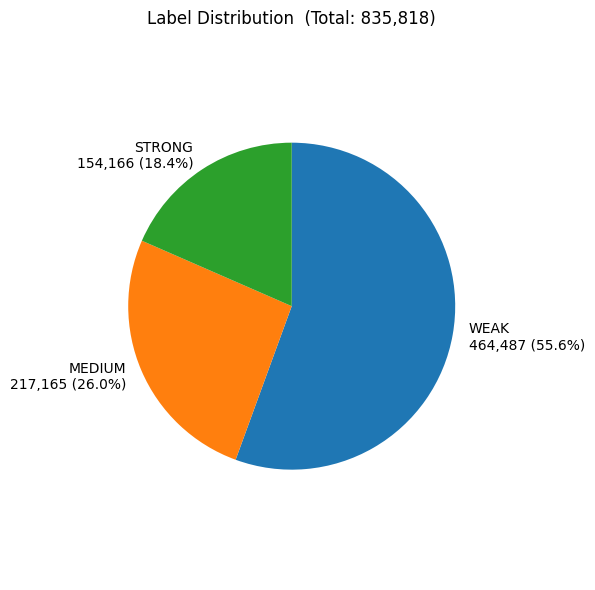


Class           Count    Percent
--------------------------------
WEAK          464,487      55.6%
MEDIUM        217,165      26.0%
STRONG        154,166      18.4%
--------------------------------
TOTAL         835,818     100.0%


In [3]:
print(f"\n Label distribution:")
LABEL_NAMES = {0: "WEAK", 1: "MEDIUM", 2: "STRONG"}
labels_order = list(LABEL_NAMES.keys())

counts = df_dataset['strength'].value_counts().reindex(labels_order)
total = counts.sum()
pcts = counts / total * 100

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=[
        f"{LABEL_NAMES[k]}\n{counts[k]:,} ({p:.1f}%)"   # ← count + percentage
        for k, p in zip(labels_order, pcts)
    ],
    autopct=None,
    startangle=90,
    counterclock=False
)
plt.title(f"Label Distribution  (Total: {total:,})")   # ← total in title
plt.axis('equal')
plt.tight_layout()
plt.show()

# Also print a clean table to console
print(f"\n{'Class':<10} {'Count':>10} {'Percent':>10}")
print("-" * 32)
for k in labels_order:
    print(f"{LABEL_NAMES[k]:<10} {counts[k]:>10,} {pcts[k]:>9.1f}%")
print("-" * 32)
print(f"{'TOTAL':<10} {total:>10,} {'100.0%':>10}")

In [ ]:
print(f"\n Shape     : {df_dataset.shape}")
print(f" Columns   : {list(df_dataset.columns)}")
print(f" Duplicates: {df_dataset.duplicated().sum():,}")
print(f" Nulls     :\n{df_dataset.isnull().sum()}")


 Shape     : (835818, 3)
 Columns   : ['password', 'strength', 'source']
 Duplicates: 0
 Nulls     :
password    0
strength    0
source      0
dtype: int64



 Label distribution:


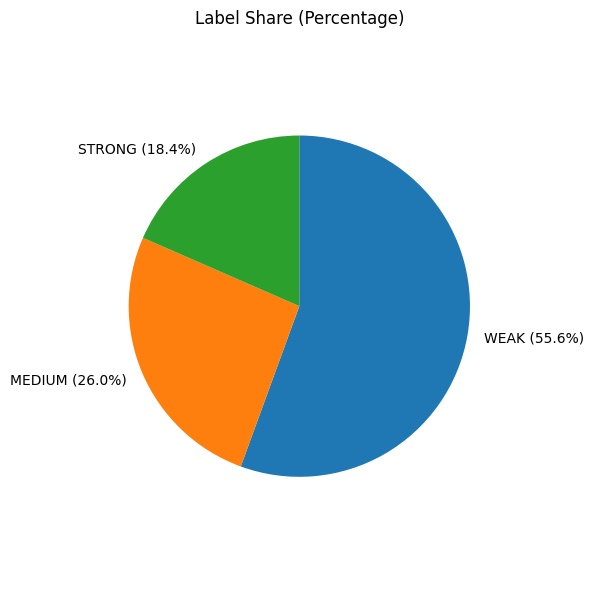

In [ ]:
print(f"\n Label distribution:")
LABEL_NAMES = {0: "WEAK", 1: "MEDIUM", 2: "STRONG"}
labels_order = list(LABEL_NAMES.keys())

counts = df_dataset['strength'].value_counts().reindex(labels_order)
total = counts.sum()
pcts = counts / total * 100

plt.figure(figsize=(6,6))
plt.pie(counts, labels=[f"{LABEL_NAMES[k]} ({p:.1f}%)" for k,p in zip(labels_order, pcts)],
        autopct=None, startangle=90, counterclock=False)
plt.title("Label Share (Percentage)")
plt.axis('equal')
plt.tight_layout()
plt.show()




 Source distribution:


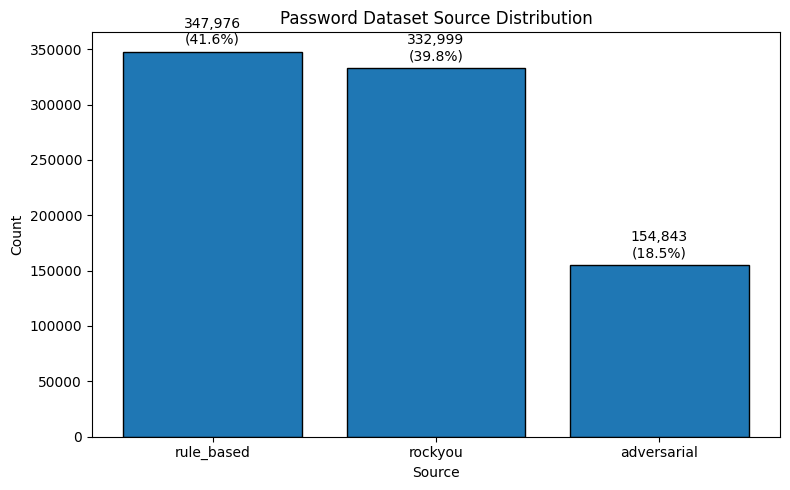

In [ ]:
print(f"\n Source distribution:")
source_counts = df_dataset['source'].value_counts()
total = len(df_dataset)
percentages = source_counts / total * 100

plt.figure(figsize=(8,5))
bars = plt.bar(source_counts.index, source_counts.values, edgecolor='black')

plt.title("Password Dataset Source Distribution")
plt.xlabel("Source")
plt.ylabel("Count")

for bar, count, pct in zip(bars, source_counts.values, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + total*0.005,
             f"{count:,}\n({pct:.1f}%)",
             ha='center',
             va='bottom',
             fontsize=10)

plt.tight_layout()
plt.show()


 Password length stats:


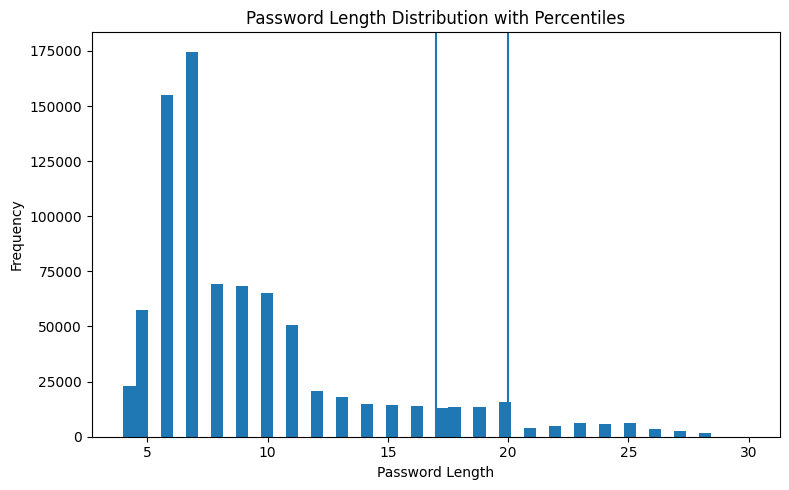

90th percentile: 17.0
95th percentile: 20.0


In [ ]:
print(f"\n Password length stats:")

lengths = df_dataset['pwd_len']

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=50)

# Percentiles
p90 = np.percentile(lengths, 90)
p95 = np.percentile(lengths, 95)

plt.axvline(p90)
plt.axvline(p95)

plt.title("Password Length Distribution with Percentiles")
plt.xlabel("Password Length")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("90th percentile:", p90)
print("95th percentile:", p95)

In [ ]:
df_dataset['pwd_len'] = df_dataset['password'].astype(str).apply(len)
print(df_dataset['pwd_len'].describe().round(2))

count    835818.00
mean          9.45
std           4.74
min           4.00
25%           6.00
50%           8.00
75%          11.00
max          30.00
Name: pwd_len, dtype: float64


Train / Val / Test Split (70/15/15)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_dataset['password'].values
y = df_dataset['strength'].values

# split 70% for training and 30% for test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# split the 30% of test to 15% for validation and the other 15% for test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print(f"   Train : {len(X_train):>8,}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Val   : {len(X_val):>8,}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test  : {len(X_test):>8,}  ({len(X_test)/len(X)*100:.1f}%)")

   Train :  585,072  (70.0%)
   Val   :  125,373  (15.0%)
   Test  :  125,373  (15.0%)


Tokenization

In [ ]:
!pip install tensorflow -q

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import json


In [ ]:

all_chars = set()
for pwd in X_train:
    all_chars.update(set(pwd))

PAD_TOKEN = 0  # padding
UNK_TOKEN = 1  # unknown

# char → idx mapping
sorted_chars = sorted(all_chars)
char_to_idx = {ch: idx+2 for idx, ch in enumerate(sorted_chars)}
char_to_idx['<PAD>'] = PAD_TOKEN
char_to_idx['<UNK>'] = UNK_TOKEN

idx_to_char = {idx: ch for ch, idx in char_to_idx.items()}

VOCAB_SIZE = len(char_to_idx)

print(f" Vocabulary built from training set:")
print(f"   Unique chars  : {len(all_chars)}")
print(f"   Vocab size    : {VOCAB_SIZE} (chars + PAD + UNK)")
print("\n Sample char→idx mapping:")
for ch, idx in list(char_to_idx.items())[:15]:
    display = repr(ch)
    print(f"   '{display}' → {idx}")


 Vocabulary built from training set:
   Unique chars  : 123
   Vocab size    : 125 (chars + PAD + UNK)

 Sample char→idx mapping:
   ''!'' → 2
   ''"'' → 3
   ''#'' → 4
   ''$'' → 5
   ''%'' → 6
   ''&'' → 7
   '"'"' → 8
   ''('' → 9
   '')'' → 10
   ''*'' → 11
   ''+'' → 12
   '','' → 13
   ''-'' → 14
   ''.'' → 15
   ''/'' → 16


In [ ]:
import pickle

VOCAB_PATH = "/content/drive/MyDrive/password_project/models/char_vocab.pkl"

with open(VOCAB_PATH, "wb") as f:
    pickle.dump(char_to_idx, f)

print("✅ Vocabulary saved")

✅ Vocabulary saved


In [ ]:
# convert password string to list of integer indices
def tokenize(pwd: str) -> list:

    return [char_to_idx.get(ch, UNK_TOKEN) for ch in pwd]

In [ ]:
X_train_tok = [tokenize(pwd) for pwd in X_train]
X_val_tok   = [tokenize(pwd) for pwd in X_val]
X_test_tok  = [tokenize(pwd) for pwd in X_test]

In [ ]:
MAX_LEN = 30
X_train_seq = pad_sequences(X_train_tok, maxlen=MAX_LEN, padding='post', truncating='post', value=PAD_TOKEN)
X_val_seq   = pad_sequences(X_val_tok,   maxlen=MAX_LEN, padding='post', truncating='post', value=PAD_TOKEN)
X_test_seq  = pad_sequences(X_test_tok,  maxlen=MAX_LEN, padding='post', truncating='post', value=PAD_TOKEN)

In [ ]:
X_train_mask = (X_train_seq != PAD_TOKEN).astype(np.float32)
X_val_mask   = (X_val_seq != PAD_TOKEN).astype(np.float32)
X_test_mask  = (X_test_seq != PAD_TOKEN).astype(np.float32)

In [ ]:
print("\n Tokenization + Padding Example:")
for i in range(3):
    print(f"   '{X_train[i]}' → {X_train_seq[i]}  | length mask: {X_train_mask[i]}")


 Tokenization + Padding Example:
   'pgNAnZW9' → [81 72 47 34 79 59 56 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]  | length mask: [1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
   '04298910' → [17 21 19 26 25 26 18 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]  | length mask: [1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
   'Sophia#2024' → [52 80 81 73 74 66  4 19 17 19 21  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]  | length mask: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


In [ ]:
from tensorflow.keras.utils import to_categorical
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from datetime import datetime

In [ ]:
NUM_CLASSES = 3
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f" Label encoding (one-hot):")
print(f"   y_train_cat shape : {y_train_cat.shape}")
print(f"   Sample: label={y_train[0]} → {y_train_cat[0]}")

 Label encoding (one-hot):
   y_train_cat shape : (585072, 3)
   Sample: label=1 → [0. 1. 0.]


In [ ]:
def analyze_class_distribution(y_split, split_name="Train"):
    counts = Counter(y_split)
    total = len(y_split)
    imbalance_ratios = {l: counts[l]/total for l in [0,1,2]}
    max_ratio = max(imbalance_ratios.values())
    min_ratio = min(imbalance_ratios.values())
    imbalance_factor = max_ratio / min_ratio

    print(f"\n {split_name} Class Distribution:")
    for label in [0,1,2]:
        n = counts[label]
        pct = imbalance_ratios[label]*100
        bar = "█" * int(pct/2)  # scale bar to 50 chars
        print(f"   [{label}] {LABEL_NAMES[label]:<8}: {n:>8,} ({pct:.1f}%)  {bar}")

    print(f"   Imbalance factor: {imbalance_factor:.2f}x")
    return counts, imbalance_factor

In [ ]:
train_counts, train_imbalance = analyze_class_distribution(y_train, "Train")


 Train Class Distribution:
   [0] WEAK    :  325,141 (55.6%)  ███████████████████████████
   [1] MEDIUM  :  152,015 (26.0%)  ████████████
   [2] STRONG  :  107,916 (18.4%)  █████████
   Imbalance factor: 3.01x


In [ ]:
if train_imbalance > 3:
    print("   ⚠️  Significant imbalance detected → applying class weights")
else:
    print("   ✅ Imbalance acceptable → no resampling needed")

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1,2]),
    y=y_train
)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(class_weights_array)}

   ⚠️  Significant imbalance detected → applying class weights


In [ ]:
print("\n  Class weights for training:")
for label, weight in CLASS_WEIGHTS.items():
    print(f"   [{label}] {LABEL_NAMES[label]:<8} → weight = {weight:.4f}")


  Class weights for training:
   [0] WEAK     → weight = 0.5998
   [1] MEDIUM   → weight = 1.2829
   [2] STRONG   → weight = 1.8072


Oversampling Minority Classes

In [ ]:
df_train = pd.DataFrame({
    'password': X_train,
    'strength': y_train
})

In [ ]:
df_weak   = df_train[df_train['strength'] == 0]   # majority class
df_medium = df_train[df_train['strength'] == 1]   # minority
df_strong = df_train[df_train['strength'] == 2]   # minority

In [ ]:
from sklearn.utils import resample

n_target = len(df_weak)  # balance to majority class count

df_medium_up = resample(df_medium,
                        replace=True,
                        n_samples=n_target,
                        random_state=42)

df_strong_up = resample(df_strong,
                        replace=True,
                        n_samples=n_target,
                        random_state=42)

In [ ]:
df_train_bal = pd.concat([df_weak, df_medium_up, df_strong_up])
df_train_bal = df_train_bal.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
X_train_bal = df_train_bal['password'].tolist()
y_train_bal = df_train_bal['strength'].to_numpy()

In [ ]:
def tokenize(pwd):
    return [char_to_idx.get(ch, UNK_TOKEN) for ch in pwd]

X_train_tok_bal = [tokenize(pwd) for pwd in X_train_bal]

MAX_LEN = 30
X_train_seq_bal = pad_sequences(X_train_tok_bal, maxlen=MAX_LEN, padding='post', truncating='post')

In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1,2]),
    y=y_train_bal
)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(class_weights_array)}

In [ ]:
print(type(y_train_bal))
print(y_train_bal[:5])

<class 'numpy.ndarray'>
[0 0 2 1 2]


In [ ]:
NUM_CLASSES = 3

y_train_cat_bal = to_categorical(y_train_bal, num_classes=NUM_CLASSES)
y_val_cat       = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_cat      = to_categorical(y_test, num_classes=NUM_CLASSES)

print("y_train shape:", y_train_cat_bal.shape)

y_train shape: (975423, 3)


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/password_project"
os.makedirs(SAVE_DIR, exist_ok=True)

np.savez_compressed(
    f"{SAVE_DIR}/preprocessed_balanced_data.npz",
    X_train=X_train_seq_bal,
    X_val=X_val_seq,
    X_test=X_test_seq,
    y_train=y_train_cat_bal,
    y_val=y_val_cat,
    y_test=y_test_cat
)

## BiLSTM Training for Password Strength

In [ ]:
from google.colab import drive
import numpy as np

# Mount Google Drive
drive.mount('/content/drive')

# Load preprocessed arrays
SAVE_DIR = "/content/drive/MyDrive/password_project"
data = np.load(f"{SAVE_DIR}/preprocessed_balanced_data.npz", allow_pickle=True)

X_train = data['X_train']
X_val   = data['X_val']
X_test  = data['X_test']
y_train = data['y_train']
y_val   = data['y_val']
y_test  = data['y_test']

print(f"✅ Data loaded:")
print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   X_val  : {X_val.shape},   y_val  : {y_val.shape}")
print(f"   X_test : {X_test.shape},  y_test : {y_test.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data loaded:
   X_train: (975423, 30), y_train: (975423, 3)
   X_val  : (125373, 30),   y_val  : (125373, 3)
   X_test : (125373, 30),  y_test : (125373, 3)


In [ ]:
import tensorflow as tf

MAX_LEN     = X_train.shape[1]      # sequence length (e.g., 30)
VOCAB_SIZE  = len(char_to_idx)      # vocabulary size including PAD/UNK
EMBED_DIM   = 64                     # embedding dimension
LSTM_UNITS  = 128                    # BiLSTM hidden units
NUM_CLASSES = y_train.shape[1]       # 3 (WEAK, MEDIUM, STRONG)
DROPOUT     = 0.3
BATCH_SIZE  = 128
EPOCHS      = 15

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout

inputs = Input(shape=(MAX_LEN,), name='password_input')
x = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True, name='char_embedding')(inputs)
x = Bidirectional(LSTM(LSTM_UNITS, return_sequences=False, dropout=DROPOUT, recurrent_dropout=DROPOUT))(x)
x = Dense(64, activation='relu')(x)
x = Dropout(DROPOUT)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ password_input      │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embedding      │ (None, 30, 64)    │      8,000 │ password_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 30)        │          0 │ password_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 256)       │    197,632 │ char_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     16,448 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 222,275 (868.26 KB)

 Trainable params: 222,275 (868.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

# Save the best model
checkpoint = ModelCheckpoint(f"{SAVE_DIR}/bilstm_best_model.h5", monitor='val_loss', save_best_only=True)

# Log training history
csv_logger = CSVLogger(f"{SAVE_DIR}/bilstm_training_log.csv")

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
CLASS_WEIGHTS = {0:1.0, 1:1.0, 2:1.0}  # balanced after oversampling

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=[early_stop, checkpoint, csv_logger]
)

SAVE_DIR = "/content/drive/MyDrive/password_project/models"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = f"{SAVE_DIR}/bilstm_password_model.keras"

model.save(MODEL_PATH)

print("✅ Model saved to Drive:")
print(MODEL_PATH)

Epoch 1/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9736 - loss: 0.0730

7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2666s 350ms/step - accuracy: 0.9736 - loss: 0.0730 - val_accuracy: 0.9845 - val_loss: 0.0300
Epoch 2/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9899 - loss: 0.0245

7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2653s 348ms/step - accuracy: 0.9899 - loss: 0.0245 - val_accuracy: 0.9847 - val_loss: 0.0279
Epoch 3/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.9912 - loss: 0.0206

7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2638s 346ms/step - accuracy: 0.9912 - loss: 0.0206 - val_accuracy: 0.9909 - val_loss: 0.0225
Epoch 4/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9932 - loss: 0.0170

7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2668s 347ms/step - accuracy: 0.9932 - loss: 0.0170 - val_accuracy: 0.9936 - val_loss: 0.0171
Epoch 5/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.9949 - loss: 0.0138

...

7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2642s 347ms/step - accuracy: 0.9972 - loss: 0.0084 - val_accuracy: 0.9976 - val_loss: 0.0088
Epoch 8/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9979 - loss: 0.0071

7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2617s 343ms/step - accuracy: 0.9979 - loss: 0.0071 - val_accuracy: 0.9981 - val_loss: 0.0070
Epoch 9/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.9982 - loss: 0.0057

7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2631s 345ms/step - accuracy: 0.9982 - loss: 0.0057 - val_accuracy: 0.9983 - val_loss: 0.0065
Epoch 10/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9985 - loss: 0.0050

7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2620s 344ms/step - accuracy: 0.9985 - loss: 0.0050 - val_accuracy: 0.9984 - val_loss: 0.0061
Epoch 11/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2666s 344ms/step - accuracy: 0.9987 - loss: 0.0046 - val_accuracy: 0.9986 - val_loss: 0.0061
Epoch 12/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9988 - loss: 0.0040

7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2678s 347ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.9987 - val_loss: 0.0056
Epoch 13/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2622s 344ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.9987 - val_loss: 0.0058
Epoch 14/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2604s 342ms/step - accuracy: 0.9988 - loss: 0.0045 - val_accuracy: 0.9987 - val_loss: 0.0060
Epoch 15/15
7621/7621 ━━━━━━━━━━━━━━━━━━━━ 2616s 343ms/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.9987 - val_loss: 0.0057
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 12.
✅ Model saved to Drive:
/content/drive/MyDrive/password_project/models/bilstm_password_model.keras


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/password_project/models"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = f"{SAVE_DIR}/bilstm_password_model.keras"

In [ ]:
model.save(MODEL_PATH)

print("✅ Model saved to Drive:")
print(MODEL_PATH)

✅ Model saved to Drive:
/content/drive/MyDrive/password_project/models/bilstm_password_model.keras


In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE)
print(f"\n📌 Test Accuracy : {test_acc*100:.2f}%")
print(f"📌 Test Loss     : {test_loss:.4f}")

980/980 ━━━━━━━━━━━━━━━━━━━━ 83s 85ms/step - accuracy: 0.9987 - loss: 0.0045

📌 Test Accuracy : 99.87%
📌 Test Loss     : 0.0044


Quick test

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/password_project/models/bilstm_password_model.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded successfully")

✅ Model loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 13 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import pickle

VOCAB_PATH = "/content/drive/MyDrive/password_project/models/char_vocab.pkl"

with open(VOCAB_PATH, "rb") as f:
    char_to_idx = pickle.load(f)

print("✅ Vocabulary loaded")

✅ Vocabulary loaded


In [ ]:
MAX_LEN = 30   # same value used during training
UNK = 1        # unknown token index

def encode_password(password):
    seq = [char_to_idx.get(c, UNK) for c in password]

    # padding
    if len(seq) < MAX_LEN:
        seq = seq + [0]*(MAX_LEN-len(seq))
    else:
        seq = seq[:MAX_LEN]

    return seq

In [ ]:
classes = ["WEAK", "MEDIUM", "STRONG"]

In [ ]:
import numpy as np

def predict_password(password):

    seq = encode_password(password)
    seq = np.array([seq])

    prediction = model.predict(seq, verbose=0)

    class_id = np.argmax(prediction)
    confidence = prediction[0][class_id]

    print("Password:", password)
    print("Prediction:", classes[class_id])
    for i, c in enumerate(classes):
        print(f"{c}: {prediction[0][i]*100:.4f}%")

In [ ]:
password = input("Enter a password: ")

predict_password(password)


Enter a password: hjkhhljkh
Password: hjkhhljkh
Prediction: MEDIUM
WEAK: 34.41%
MEDIUM: 65.51%
STRONG: 0.08%
